In [1]:

# Load necessary libraries and set up the analysis environment
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Environment setup complete")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Environment setup complete
NumPy version: 1.26.4
Pandas version: 2.3.2


In [2]:

# Analysis Plan for L_DH Causal Perturbation Analysis
print("=" * 80)
print("ANALYSIS PLAN: Causal Architecture of L_DH Function")
print("=" * 80)
print()
print("OBJECTIVE:")
print("Determine whether the non-multiplicative Davenport-Heilbronn L-function follows")
print("the density-based S₂/S₃ dominance rule established for multiplicative functions,")
print("or exhibits a distinct causal architecture.")
print()
print("STEPS:")
print("1. Load validated L_DH coefficients (N=10,000)")
print("2. Extend coefficients to N=10⁶ using the analytical formula")
print("3. Load pre-computed Ω(n) values for ω-class decomposition")
print("4. Identify top 20 peaks of |L_DH(1/2+it)| in range t ∈ [10⁶, 2×10⁶]")
print(" - Use two-step approach: coarse grid search + local refinement")
print(" - Grid density: ~2000 points based on documented success at N=10⁶")
print("5. At each peak location t*:")
print(" a. Compute baseline |D_F(t*)|")
print(" b. Decompose into ω-class sums S₂, S₃, S₄")
print(" c. Apply causal perturbation: multiply each S_k by e^(iπ) = -1")
print(" d. Recompute |D_F(t*)| with perturbation")
print(" e. Calculate % reduction: 100 × (|D_baseline| - |D_perturbed|) / |D_baseline|")
print("6. Aggregate results: mean reduction across 20 peaks for each ω-class")
print("7. Compare to known patterns:")
print(" - Sparse multiplicative (Möbius): S₂-dominant (~60.8% non-zero)")
print(" - Dense multiplicative (zeta, f_canon_rand): S₃-dominant (100% non-zero)")
print("8. Determine L_DH causal structure and dominant ω-class")
print()
print("METHODS:")
print("- Kahan compensated summation for all Dirichlet sums (mandatory)")
print("- Peak finding: scipy.optimize.minimize_scalar with bounded method")
print("- Statistical reporting: mean ± std for reduction percentages")
print()
print("LIMITATIONS:")
print("- Computational cost at N=10⁶ is significant")
print("- L_DH coefficient density and structure may affect peak locations")
print("- Analysis limited to S₂, S₃, S₄ (higher classes contribute less)")
print("=" * 80)


ANALYSIS PLAN: Causal Architecture of L_DH Function

OBJECTIVE:
Determine whether the non-multiplicative Davenport-Heilbronn L-function follows
the density-based S₂/S₃ dominance rule established for multiplicative functions,
or exhibits a distinct causal architecture.

STEPS:
1. Load validated L_DH coefficients (N=10,000)
2. Extend coefficients to N=10⁶ using the analytical formula
3. Load pre-computed Ω(n) values for ω-class decomposition
4. Identify top 20 peaks of |L_DH(1/2+it)| in range t ∈ [10⁶, 2×10⁶]
 - Use two-step approach: coarse grid search + local refinement
 - Grid density: ~2000 points based on documented success at N=10⁶
5. At each peak location t*:
 a. Compute baseline |D_F(t*)|
 b. Decompose into ω-class sums S₂, S₃, S₄
 c. Apply causal perturbation: multiply each S_k by e^(iπ) = -1
 d. Recompute |D_F(t*)| with perturbation
 e. Calculate % reduction: 100 × (|D_baseline| - |D_perturbed|) / |D_baseline|
6. Aggregate results: mean reduction across 20 peaks for each ω-clas

In [3]:

# Load the validated L_DH coefficients
with open('a_DH_coefficients_N10000_validated.pkl', 'rb') as f:
 a_DH_10k = pickle.load(f)

print(f"Loaded L_DH coefficients: shape = {a_DH_10k.shape}, dtype = {a_DH_10k.dtype}")
print(f"First 10 coefficients: {a_DH_10k[:10]}")
print(f"Non-zero coefficients: {np.count_nonzero(a_DH_10k)} / {len(a_DH_10k)} ({100*np.count_nonzero(a_DH_10k)/len(a_DH_10k):.1f}%)")


AttributeError: 'dict' object has no attribute 'shape'

In [4]:

# Check the structure of the loaded data
print(f"Type of loaded data: {type(a_DH_10k)}")
if isinstance(a_DH_10k, dict):
 print(f"Dictionary keys: {a_DH_10k.keys()}")
 for key, value in a_DH_10k.items():
 print(f" {key}: type = {type(value)}, ", end='')
 if hasattr(value, 'shape'):
 print(f"shape = {value.shape}, dtype = {value.dtype}")
 else:
 print(f"value = {value}")


Type of loaded data: <class 'dict'>
Dictionary keys: dict_keys(['N', 'kappa', 'coefficients', 'formula', 'chi_description', 'validation_status'])
 N: type = <class 'int'>, value = 10000
 kappa: type = <class 'float'>, value = 0.28407904384041227
 coefficients: type = <class 'dict'>, value = {1: (1+0j), 2: (0.28407904384041227+0j), 3: (-0.28407904384041227+0j), 4: (-1+0j), 5: 0j, 6: (1+0j), 7: (0.28407904384041227+0j), 8: (-0.28407904384041227+0j), 9: (-1+0j), 10: 0j, 11: (1+0j), 12: (0.28407904384041227+0j), 13: (-0.28407904384041227+0j), 14: (-1+0j), 15: 0j, 16: (1+0j), 17: (0.28407904384041227+0j), 18: (-0.28407904384041227+0j), 19: (-1+0j), 20: 0j, 21: (1+0j), 22: (0.28407904384041227+0j), 23: (-0.28407904384041227+0j), 24: (-1+0j), 25: 0j, 26: (1+0j), 27: (0.28407904384041227+0j), 28: (-0.28407904384041227+0j), 29: (-1+0j), 30: 0j, 31: (1+0j), 32: (0.28407904384041227+0j), 33: (-0.28407904384041227+0j), 34: (-1+0j), 35: 0j, 36: (1+0j), 37: (0.28407904384041227+0j), 38: (-0.28407904

In [5]:

# Extract coefficients dictionary and convert to array format
coeff_dict = a_DH_10k['coefficients']
kappa = a_DH_10k['kappa']

# Create array with 0-indexing (a[0] = 0, a[1] = a_1, etc.)
a_DH_10k_array = np.zeros(10001, dtype=complex)
for n, val in coeff_dict.items():
 a_DH_10k_array[n] = val

print(f"Converted to array: shape = {a_DH_10k_array.shape}, dtype = {a_DH_10k_array.dtype}")
print(f"κ (kappa) = {kappa:.10f}")
print(f"First 20 coefficients:")
for i in range(1, 21):
 print(f" a_{i} = {a_DH_10k_array[i]}")

# Count non-zero coefficients (excluding a_0)
non_zero = np.count_nonzero(a_DH_10k_array[1:])
total = len(a_DH_10k_array[1:])
print(f"\nNon-zero coefficients: {non_zero} / {total} ({100*non_zero/total:.1f}%)")


Converted to array: shape = (10001,), dtype = complex128
κ (kappa) = 0.2840790438
First 20 coefficients:
 a_1 = (1+0j)
 a_2 = (0.28407904384041227+0j)
 a_3 = (-0.28407904384041227+0j)
 a_4 = (-1+0j)
 a_5 = 0j
 a_6 = (1+0j)
 a_7 = (0.28407904384041227+0j)
 a_8 = (-0.28407904384041227+0j)
 a_9 = (-1+0j)
 a_10 = 0j
 a_11 = (1+0j)
 a_12 = (0.28407904384041227+0j)
 a_13 = (-0.28407904384041227+0j)
 a_14 = (-1+0j)
 a_15 = 0j
 a_16 = (1+0j)
 a_17 = (0.28407904384041227+0j)
 a_18 = (-0.28407904384041227+0j)
 a_19 = (-1+0j)
 a_20 = 0j

Non-zero coefficients: 8000 / 10000 (80.0%)


In [6]:

# Extend L_DH coefficients to N=10^6 using the analytical formula
# L_DH: a_n = ((1-iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n)
# where χ is a primitive character mod 5 of order 4

N = 10**6
print(f"Generating L_DH coefficients up to N = {N:,}")

# Define the primitive character mod 5 of order 4
# For n ≡ 0 (mod 5): χ(n) = 0
# For n ≡ 1 (mod 5): χ(n) = 1
# For n ≡ 2 (mod 5): χ(n) = i
# For n ≡ 3 (mod 5): χ(n) = -i
# For n ≡ 4 (mod 5): χ(n) = -1

def chi_mod5(n):
 """Primitive character mod 5 of order 4"""
 remainder = n % 5
 if remainder == 0:
 return 0
 elif remainder == 1:
 return 1
 elif remainder == 2:
 return 1j
 elif remainder == 3:
 return -1j
 elif remainder == 4:
 return -1
 
def compute_a_DH(n, kappa):
 """Compute Davenport-Heilbronn coefficient a_n"""
 chi_n = chi_mod5(n)
 chi_bar_n = np.conj(chi_n)
 
 factor1 = (1 - 1j*kappa) / 2
 factor2 = (1 + 1j*kappa) / 2
 
 return factor1 * chi_n + factor2 * chi_bar_n

# Generate coefficients (0-indexed: a[0]=0, a[1]=a_1, etc.)
a_DH = np.zeros(N+1, dtype=complex)
for n in range(1, N+1):
 a_DH[n] = compute_a_DH(n, kappa)
 
print(f"Generated {N:,} coefficients")

# Verify against the first 10k coefficients
max_diff = np.max(np.abs(a_DH[:10001] - a_DH_10k_array))
print(f"Max difference from validated N=10k coefficients: {max_diff:.2e}")

# Analyze coefficient properties
non_zero = np.count_nonzero(a_DH[1:])
print(f"Non-zero coefficients: {non_zero:,} / {N:,} ({100*non_zero/N:.1f}%)")
print(f"Coefficient values are real: {np.allclose(a_DH.imag, 0)}")
print(f"Unique non-zero values: {len(np.unique(a_DH[np.nonzero(a_DH)]))}")


Generating L_DH coefficients up to N = 1,000,000


Generated 1,000,000 coefficients
Max difference from validated N=10k coefficients: 0.00e+00
Non-zero coefficients: 800,000 / 1,000,000 (80.0%)
Coefficient values are real: True
Unique non-zero values: 4


In [7]:

# Load pre-computed Ω(n) values
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values = pickle.load(f)

print(f"Loaded Ω(n) values: shape = {omega_values.shape}, dtype = {omega_values.dtype}")
print(f"Note: 0-based indexing, omega_values[i] = Ω(i+1)")
print(f"First 20 Ω values:")
for i in range(20):
 print(f" Ω({i+1}) = {omega_values[i]}")

# Verify consistency
print(f"\nVerification: Ω(12) should be 3 (2²×3): {omega_values[11]}")
print(f"Verification: Ω(16) should be 4 (2⁴): {omega_values[15]}")


Loaded Ω(n) values: shape = (1000000,), dtype = int64
Note: 0-based indexing, omega_values[i] = Ω(i+1)
First 20 Ω values:
 Ω(1) = 0
 Ω(2) = 1
 Ω(3) = 1
 Ω(4) = 2
 Ω(5) = 1
 Ω(6) = 2
 Ω(7) = 1
 Ω(8) = 3
 Ω(9) = 2
 Ω(10) = 2
 Ω(11) = 1
 Ω(12) = 3
 Ω(13) = 1
 Ω(14) = 2
 Ω(15) = 2
 Ω(16) = 4
 Ω(17) = 1
 Ω(18) = 3
 Ω(19) = 1
 Ω(20) = 3

Verification: Ω(12) should be 3 (2²×3): 3
Verification: Ω(16) should be 4 (2⁴): 4


In [8]:

# Implement Kahan compensated summation for Dirichlet polynomial evaluation
def kahan_sum(values):
 """
 Kahan compensated summation for improved numerical precision.
 Input: array of complex values
 Output: sum with reduced floating point errors
 """
 total = 0.0 + 0.0j
 compensation = 0.0 + 0.0j
 
 for value in values:
 y = value - compensation
 temp = total + y
 compensation = (temp - total) - y
 total = temp
 
 return total

def evaluate_dirichlet_L_DH(t, a, N):
 """
 Evaluate Dirichlet polynomial: D_F(t; N) = Σ_{n=1}^N a_n / n^(1/2 + it)
 Uses Kahan summation for numerical precision.
 
 Parameters:
 - t: evaluation point (real)
 - a: coefficient array (0-indexed, a[n] corresponds to a_n)
 - N: truncation parameter
 
 Returns: complex value D_F(t; N)
 """
 n_values = np.arange(1, N+1)
 exponents = -0.5 - 1j * t
 terms = a[1:N+1] * np.power(n_values, exponents, dtype=complex)
 
 return kahan_sum(terms)

# Test on a simple value
t_test = 1000.0
D_test = evaluate_dirichlet_L_DH(t_test, a_DH, 1000)
print(f"Test evaluation: |D_F(t={t_test}, N=1000)| = {np.abs(D_test):.6f}")


Test evaluation: |D_F(t=1000.0, N=1000)| = 0.911651


In [9]:

# Step 1: Coarse grid search for peak candidates
# Use range t ∈ [N, 2N] = [10⁶, 2×10⁶] with ~2000 grid points

t_min = N
t_max = 2 * N
n_grid = 2000

print(f"Coarse grid search for L_DH peaks")
print(f"Range: t ∈ [{t_min:,}, {t_max:,}]")
print(f"Grid points: {n_grid}")

t_grid = np.linspace(t_min, t_max, n_grid)
magnitudes = np.zeros(n_grid)

print("Computing magnitudes on grid...")
for i, t in enumerate(t_grid):
 D_val = evaluate_dirichlet_L_DH(t, a_DH, N)
 magnitudes[i] = np.abs(D_val)
 
 if (i+1) % 400 == 0:
 print(f" Progress: {i+1}/{n_grid} ({100*(i+1)/n_grid:.1f}%)")

print(f"Grid search complete")
print(f"Min magnitude: {np.min(magnitudes):.6f}")
print(f"Max magnitude: {np.max(magnitudes):.6f}")
print(f"Mean magnitude: {np.mean(magnitudes):.6f}")


Coarse grid search for L_DH peaks
Range: t ∈ [1,000,000, 2,000,000]
Grid points: 2000
Computing magnitudes on grid...


 Progress: 400/2000 (20.0%)


 Progress: 800/2000 (40.0%)


 Progress: 1200/2000 (60.0%)


 Progress: 1600/2000 (80.0%)


 Progress: 2000/2000 (100.0%)
Grid search complete
Min magnitude: 0.010374
Max magnitude: 14.632833
Mean magnitude: 1.900890


In [10]:

# Identify top candidate peaks from grid search
# Use scipy.signal.find_peaks or manual method to identify local maxima

from scipy.signal import find_peaks

# Find local maxima in the grid
peaks_idx, properties = find_peaks(magnitudes, prominence=0.5)

print(f"Found {len(peaks_idx)} peaks with prominence > 0.5")

# Sort by magnitude to get top candidates
peak_magnitudes = magnitudes[peaks_idx]
peak_t_values = t_grid[peaks_idx]

# Get top 25 candidates (will refine to top 20)
n_candidates = min(25, len(peaks_idx))
top_indices = np.argsort(peak_magnitudes)[-n_candidates:][::-1]

candidate_t = peak_t_values[top_indices]
candidate_mag = peak_magnitudes[top_indices]

print(f"\nTop {n_candidates} peak candidates from coarse grid:")
for i in range(min(10, n_candidates)):
 print(f" {i+1}. t = {candidate_t[i]:,.1f}, |D_F| = {candidate_mag[i]:.6f}")


Found 570 peaks with prominence > 0.5

Top 25 peak candidates from coarse grid:
 1. t = 1,831,415.7, |D_F| = 14.632833
 2. t = 1,538,769.4, |D_F| = 14.464610
 3. t = 1,331,165.6, |D_F| = 12.980364
 4. t = 1,974,987.5, |D_F| = 12.005742
 5. t = 1,115,057.5, |D_F| = 12.002981
 6. t = 1,648,824.4, |D_F| = 11.380430
 7. t = 1,173,086.5, |D_F| = 11.145658
 8. t = 1,051,025.5, |D_F| = 11.142688
 9. t = 1,451,725.9, |D_F| = 11.111179
 10. t = 1,045,522.8, |D_F| = 10.679680


In [11]:

# Step 2: Local refinement of peak locations
# For each candidate, use scipy.optimize.minimize_scalar to find precise peak

def negative_magnitude(t, a, N):
 """Negative magnitude for minimization"""
 D_val = evaluate_dirichlet_L_DH(t, a, N)
 return -np.abs(D_val)

refined_peaks = []

print("Refining peak locations with local optimization...")
for i, t_init in enumerate(candidate_t):
 # Search in a window around the grid point
 window = 1000 # Search within ±1000 of grid point
 t_lower = max(t_min, t_init - window)
 t_upper = min(t_max, t_init + window)
 
 # Use bounded optimization
 result = minimize_scalar(
 negative_magnitude,
 bounds=(t_lower, t_upper),
 args=(a_DH, N),
 method='bounded',
 options={'xatol': 0.01}
 )
 
 t_peak = result.x
 mag_peak = -result.fun
 
 refined_peaks.append({'t': t_peak, 'magnitude': mag_peak})
 
 if (i+1) % 5 == 0:
 print(f" Refined {i+1}/{n_candidates} peaks")

# Sort by magnitude and select top 20
refined_peaks.sort(key=lambda x: x['magnitude'], reverse=True)
top_20_peaks = refined_peaks[:20]

print(f"\nTop 20 refined peaks:")
for i, peak in enumerate(top_20_peaks):
 print(f" {i+1:2d}. t = {peak['t']:11.2f}, |D_F| = {peak['magnitude']:.6f}")


Refining peak locations with local optimization...


 Refined 5/25 peaks


 Refined 10/25 peaks


 Refined 15/25 peaks


 Refined 20/25 peaks


 Refined 25/25 peaks

Top 20 refined peaks:
 1. t = 1831180.60, |D_F| = 9.575233
 2. t = 1220970.14, |D_F| = 8.695597
 3. t = 1299289.59, |D_F| = 8.233213
 4. t = 1155471.91, |D_F| = 7.956813
 5. t = 1364446.34, |D_F| = 7.588311
 6. t = 1331414.54, |D_F| = 7.375767
 7. t = 1045627.46, |D_F| = 7.216120
 8. t = 1451789.24, |D_F| = 7.195275
 9. t = 1325849.56, |D_F| = 7.016750
 10. t = 1211724.26, |D_F| = 6.861308
 11. t = 1324376.71, |D_F| = 6.340917
 12. t = 1115253.96, |D_F| = 6.055289
 13. t = 1594767.05, |D_F| = 6.006940
 14. t = 1540505.49, |D_F| = 5.614126
 15. t = 1849160.77, |D_F| = 5.405731
 16. t = 1609816.26, |D_F| = 5.112099
 17. t = 1006626.06, |D_F| = 4.941022
 18. t = 1648477.09, |D_F| = 4.363390
 19. t = 1975223.49, |D_F| = 3.710858
 20. t = 1688366.23, |D_F| = 3.697919


In [12]:

# Implement ω-class decomposition and causal perturbation analysis
def decompose_omega_classes(t, a, omega_values, N, k_values=[2, 3, 4]):
 """
 Decompose Dirichlet sum into ω-class contributions.
 
 S_k = Σ_{n: Ω(n)=k} a_n / n^(1/2 + it)
 
 Parameters:
 - t: evaluation point
 - a: coefficient array (0-indexed)
 - omega_values: array of Ω(n) values (0-indexed, omega_values[i] = Ω(i+1))
 - N: truncation parameter
 - k_values: list of ω-classes to compute
 
 Returns: dictionary {k: S_k}
 """
 S_classes = {}
 
 for k in k_values:
 # Find all n ≤ N with Ω(n) = k
 # Note: omega_values[n-1] = Ω(n)
 mask = (omega_values[:N] == k)
 n_in_class = np.where(mask)[0] + 1 # Convert to 1-indexed
 
 if len(n_in_class) == 0:
 S_classes[k] = 0.0 + 0.0j
 continue
 
 # Compute sum for this class
 exponents = -0.5 - 1j * t
 terms = a[n_in_class] * np.power(n_in_class, exponents, dtype=complex)
 S_classes[k] = kahan_sum(terms)
 
 return S_classes

def causal_perturbation_analysis(t, a, omega_values, N):
 """
 Perform causal perturbation analysis by de-phasing each ω-class.
 
 Returns:
 - baseline_magnitude: |D_F(t)| without perturbation
 - reductions: dict {k: percentage reduction when S_k is de-phased}
 - S_classes: dict {k: S_k} for reference
 """
 # Compute baseline (unperturbed) magnitude
 D_baseline = evaluate_dirichlet_L_DH(t, a, N)
 baseline_magnitude = np.abs(D_baseline)
 
 # Decompose into ω-classes
 S_classes = decompose_omega_classes(t, a, omega_values, N, k_values=[2, 3, 4])
 
 # For each class, apply perturbation e^(iπ) = -1
 reductions = {}
 
 for k in [2, 3, 4]:
 # Perturb S_k by multiplying by -1 (equivalent to adding phase π)
 S_perturbed = {j: (S_classes[j] if j != k else -S_classes[j]) for j in [2, 3, 4]}
 
 # Recompute total with perturbation
 # D_perturbed = S_0 + S_1 + S_perturbed[2] + S_perturbed[3] + S_perturbed[4] + ...
 # Since we're only tracking S_2, S_3, S_4, we need to compute remaining contributions
 
 # Alternative approach: compute D_baseline - 2*S_k (since -S_k - S_k = -2*S_k)
 D_perturbed = D_baseline - 2 * S_classes[k]
 mag_perturbed = np.abs(D_perturbed)
 
 # Calculate percentage reduction
 reduction = 100 * (baseline_magnitude - mag_perturbed) / baseline_magnitude
 reductions[k] = reduction
 
 return baseline_magnitude, reductions, S_classes

# Test on first peak
t_test = top_20_peaks[0]['t']
baseline_mag, test_reductions, test_S = causal_perturbation_analysis(t_test, a_DH, omega_values, N)

print(f"Test causal analysis at t = {t_test:.2f}")
print(f"Baseline magnitude: |D_F| = {baseline_mag:.6f}")
print(f"ω-class contributions:")
for k in [2, 3, 4]:
 print(f" S_{k}: magnitude = {np.abs(test_S[k]):.6f}, reduction = {test_reductions[k]:.2f}%")


Test causal analysis at t = 1831180.60
Baseline magnitude: |D_F| = 9.575233
ω-class contributions:
 S_2: magnitude = 2.088357, reduction = 38.91%
 S_3: magnitude = 2.369071, reduction = 49.24%
 S_4: magnitude = 1.717835, reduction = 34.95%


In [13]:

# Perform causal perturbation analysis on all 20 peaks
print("Performing causal perturbation analysis on top 20 peaks...")
print("=" * 80)

results = []

for i, peak in enumerate(top_20_peaks):
 t = peak['t']
 
 baseline_mag, reductions, S_classes = causal_perturbation_analysis(t, a_DH, omega_values, N)
 
 result = {
 'peak_idx': i + 1,
 't': t,
 'baseline_magnitude': baseline_mag,
 'S2_magnitude': np.abs(S_classes[2]),
 'S3_magnitude': np.abs(S_classes[3]),
 'S4_magnitude': np.abs(S_classes[4]),
 'S2_reduction': reductions[2],
 'S3_reduction': reductions[3],
 'S4_reduction': reductions[4]
 }
 
 results.append(result)
 
 if (i+1) % 5 == 0:
 print(f" Analyzed {i+1}/20 peaks")

print("Analysis complete")
print("=" * 80)

# Convert to DataFrame for easier analysis
df_results = pd.DataFrame(results)
print(f"\nResults summary:")
print(df_results.head(10))


Performing causal perturbation analysis on top 20 peaks...


 Analyzed 5/20 peaks


 Analyzed 10/20 peaks


 Analyzed 15/20 peaks


 Analyzed 20/20 peaks
Analysis complete

Results summary:
 peak_idx t baseline_magnitude S2_magnitude S3_magnitude \
0 1 1.831181e+06 9.575233 2.088357 2.369071 
1 2 1.220970e+06 8.695597 2.545600 1.539449 
2 3 1.299290e+06 8.233213 2.455754 0.925817 
3 4 1.155472e+06 7.956813 2.100458 2.389961 
4 5 1.364446e+06 7.588311 1.929380 1.284648 
5 6 1.331415e+06 7.375767 1.396977 1.373460 
6 7 1.045627e+06 7.216120 2.497269 1.647245 
7 8 1.451789e+06 7.195275 1.335829 1.975568 
8 9 1.325850e+06 7.016750 1.465603 1.375347 
9 10 1.211724e+06 6.861308 2.390674 1.409753 

 S4_magnitude S2_reduction S3_reduction S4_reduction 
0 1.717835 38.905118 49.242730 34.953268 
1 1.208127 57.701720 34.930576 27.071844 
2 1.290122 59.646510 20.816559 30.915682 
3 1.741121 44.423320 59.476105 38.399271 
4 1.290094 45.031971 31.768781 33.852343 
5 1.022798 19.883586 30.843879 27.346847 
6 0.998966 55.220215 44.430067 26.769925 
7 1.195226 37.108769 39.420330 29.145680 
8 0.963844 41.755435 34.901229 23.523142 

In [14]:

# Calculate aggregate statistics
print("CAUSAL PERTURBATION ANALYSIS RESULTS: L_DH at N=10⁶")
print("=" * 80)
print()

# Mean reductions
mean_S2_reduction = df_results['S2_reduction'].mean()
mean_S3_reduction = df_results['S3_reduction'].mean()
mean_S4_reduction = df_results['S4_reduction'].mean()

std_S2_reduction = df_results['S2_reduction'].std()
std_S3_reduction = df_results['S3_reduction'].std()
std_S4_reduction = df_results['S4_reduction'].std()

print("MEAN REDUCTION IN |D_F| WHEN ω-CLASS IS DE-PHASED (across 20 peaks):")
print()
print(f" S₂ (Ω=2): {mean_S2_reduction:.2f}% ± {std_S2_reduction:.2f}%")
print(f" S₃ (Ω=3): {mean_S3_reduction:.2f}% ± {std_S3_reduction:.2f}%")
print(f" S₄ (Ω=4): {mean_S4_reduction:.2f}% ± {std_S4_reduction:.2f}%")
print()

# Identify dominant class
dominant_class = None
if mean_S2_reduction > mean_S3_reduction and mean_S2_reduction > mean_S4_reduction:
 dominant_class = 2
elif mean_S3_reduction > mean_S2_reduction and mean_S3_reduction > mean_S4_reduction:
 dominant_class = 3
else:
 dominant_class = 4

print(f"DOMINANT ω-CLASS: S_{dominant_class}")
print()

# Count how many peaks each class is dominant for
peak_dominance = []
for _, row in df_results.iterrows():
 reductions = [row['S2_reduction'], row['S3_reduction'], row['S4_reduction']]
 dominant_idx = np.argmax(reductions)
 peak_dominance.append(dominant_idx + 2) # +2 because we start from ω=2

from collections import Counter
dominance_counts = Counter(peak_dominance)

print("PEAK-BY-PEAK DOMINANCE:")
print(f" S₂ dominant at {dominance_counts[2]} / 20 peaks ({100*dominance_counts[2]/20:.0f}%)")
print(f" S₃ dominant at {dominance_counts[3]} / 20 peaks ({100*dominance_counts[3]/20:.0f}%)")
print(f" S₄ dominant at {dominance_counts[4]} / 20 peaks ({100*dominance_counts[4]/20:.0f}%)")
print()

# Additional statistics
print("ADDITIONAL STATISTICS:")
print(f" Mean baseline magnitude: {df_results['baseline_magnitude'].mean():.3f} ± {df_results['baseline_magnitude'].std():.3f}")
print(f" Mean |S₂|: {df_results['S2_magnitude'].mean():.3f} ± {df_results['S2_magnitude'].std():.3f}")
print(f" Mean |S₃|: {df_results['S3_magnitude'].mean():.3f} ± {df_results['S3_magnitude'].std():.3f}")
print(f" Mean |S₄|: {df_results['S4_magnitude'].mean():.3f} ± {df_results['S4_magnitude'].std():.3f}")
print()
print("=" * 80)


CAUSAL PERTURBATION ANALYSIS RESULTS: L_DH at N=10⁶

MEAN REDUCTION IN |D_F| WHEN ω-CLASS IS DE-PHASED (across 20 peaks):

 S₂ (Ω=2): 55.93% ± 16.78%
 S₃ (Ω=3): 34.13% ± 23.10%
 S₄ (Ω=4): 27.11% ± 17.18%

DOMINANT ω-CLASS: S_2

PEAK-BY-PEAK DOMINANCE:
 S₂ dominant at 14 / 20 peaks (70%)
 S₃ dominant at 6 / 20 peaks (30%)
 S₄ dominant at 0 / 20 peaks (0%)

ADDITIONAL STATISTICS:
 Mean baseline magnitude: 6.448 ± 1.617
 Mean |S₂|: 2.176 ± 0.704
 Mean |S₃|: 1.399 ± 0.480
 Mean |S₄|: 1.132 ± 0.525



In [15]:

# Create detailed comparison table
print("DETAILED RESULTS FOR EACH PEAK:")
print("=" * 100)
print(f"{'Peak':<5} {'t':<12} {'|D_F|':<8} {'|S₂|':<8} {'|S₃|':<8} {'|S₄|':<8} {'Red₂%':<8} {'Red₃%':<8} {'Red₄%':<8} {'Dom':<4}")
print("-" * 100)

for _, row in df_results.iterrows():
 reductions = [row['S2_reduction'], row['S3_reduction'], row['S4_reduction']]
 dominant_idx = np.argmax(reductions)
 dominant_label = ['S₂', 'S₃', 'S₄'][dominant_idx]
 
 print(f"{row['peak_idx']:<5} {row['t']:<12.1f} {row['baseline_magnitude']:<8.3f} "
 f"{row['S2_magnitude']:<8.3f} {row['S3_magnitude']:<8.3f} {row['S4_magnitude']:<8.3f} "
 f"{row['S2_reduction']:<8.2f} {row['S3_reduction']:<8.2f} {row['S4_reduction']:<8.2f} "
 f"{dominant_label:<4}")

print("=" * 100)
print()
print("Key: Red₂/₃/₄% = Percentage reduction in |D_F| when S₂/₃/₄ is de-phased")
print(" Dom = Dominant ω-class (highest reduction)")


DETAILED RESULTS FOR EACH PEAK:
Peak t |D_F| |S₂| |S₃| |S₄| Red₂% Red₃% Red₄% Dom 
----------------------------------------------------------------------------------------------------
1.0 1831180.6 9.575 2.088 2.369 1.718 38.91 49.24 34.95 S₃ 
2.0 1220970.1 8.696 2.546 1.539 1.208 57.70 34.93 27.07 S₂ 
3.0 1299289.6 8.233 2.456 0.926 1.290 59.65 20.82 30.92 S₂ 
4.0 1155471.9 7.957 2.100 2.390 1.741 44.42 59.48 38.40 S₃ 
5.0 1364446.3 7.588 1.929 1.285 1.290 45.03 31.77 33.85 S₂ 
6.0 1331414.5 7.376 1.397 1.373 1.023 19.88 30.84 27.35 S₃ 
7.0 1045627.5 7.216 2.497 1.647 0.999 55.22 44.43 26.77 S₂ 
8.0 1451789.2 7.195 1.336 1.976 1.195 37.11 39.42 29.15 S₃ 
9.0 1325849.6 7.017 1.466 1.375 0.964 41.76 34.90 23.52 S₂ 
10.0 1211724.3 6.861 2.391 1.410 0.799 61.59 40.01 20.00 S₂ 
11.0 1324376.7 6.341 4.073 0.948 2.242 71.07 -10.75 57.92 S₂ 
12.0 1115254.0 6.055 2.423 1.569 1.182 52.62 40.44 36.98 S₂ 
13.0 1594767.0 6.007 1.681 1.236 1.057 53.66 40.69 35.11 S₂ 
14.0 1540505.5 5.614 1.708 1.24

In [16]:

# Analyze coefficient density of L_DH and compare to known multiplicative functions
print("COEFFICIENT DENSITY COMPARISON")
print("=" * 80)
print()

# L_DH density
L_DH_nonzero = np.count_nonzero(a_DH[1:N+1])
L_DH_density = 100 * L_DH_nonzero / N

print(f"L_DH (Davenport-Heilbronn):")
print(f" Non-zero coefficients: {L_DH_nonzero:,} / {N:,}")
print(f" Density: {L_DH_density:.1f}%")
print(f" Dominant ω-class: S₂ (mean reduction: {mean_S2_reduction:.2f}%)")
print()

print("Known multiplicative function patterns (from literature):")
print()
print(" Sparse functions (~60.8% non-zero):")
print(" - Möbius function μ(n)")
print(" - f_sparse_rand")
print(" - Expected dominance: S₂")
print()
print(" Dense functions (100% non-zero):")
print(" - Riemann zeta ζ(s) (all a_n = 1)")
print(" - f_canon_rand")
print(" - Expected dominance: S₃")
print()

print(f"L_DH classification:")
print(f" With {L_DH_density:.1f}% density, L_DH is DENSER than sparse multiplicative functions")
print(f" but SPARSER than fully dense multiplicative functions.")
print()
print(f" Despite intermediate density, L_DH exhibits S₂ DOMINANCE,")
print(f" similar to the sparse multiplicative pattern.")
print()
print(f"CONCLUSION:")
print(f" The non-multiplicative L_DH does NOT follow the simple density-based rule.")
print(f" Its S₂-dominance (despite 80% density) suggests a different causal mechanism")
print(f" from multiplicative functions, potentially related to its character-based")
print(f" coefficient structure.")
print()
print("=" * 80)


COEFFICIENT DENSITY COMPARISON

L_DH (Davenport-Heilbronn):
 Non-zero coefficients: 800,000 / 1,000,000
 Density: 80.0%
 Dominant ω-class: S₂ (mean reduction: 55.93%)

Known multiplicative function patterns (from literature):

 Sparse functions (~60.8% non-zero):
 - Möbius function μ(n)
 - f_sparse_rand
 - Expected dominance: S₂

 Dense functions (100% non-zero):
 - Riemann zeta ζ(s) (all a_n = 1)
 - f_canon_rand
 - Expected dominance: S₃

L_DH classification:
 With 80.0% density, L_DH is DENSER than sparse multiplicative functions
 but SPARSER than fully dense multiplicative functions.

 Despite intermediate density, L_DH exhibits S₂ DOMINANCE,
 similar to the sparse multiplicative pattern.

CONCLUSION:
 The non-multiplicative L_DH does NOT follow the simple density-based rule.
 Its S₂-dominance (despite 80% density) suggests a different causal mechanism
 from multiplicative functions, potentially related to its character-based
 coefficient structure.



In [17]:

# Examine the coefficient structure more closely
print("DETAILED COEFFICIENT STRUCTURE ANALYSIS")
print("=" * 80)
print()

# Analyze the unique values and their distribution
unique_nonzero = np.unique(a_DH[np.nonzero(a_DH)])
print(f"Unique non-zero coefficient values:")
for val in unique_nonzero:
 count = np.sum(a_DH == val)
 percentage = 100 * count / N
 print(f" {val:+.6f}: {count:8,} occurrences ({percentage:5.2f}%)")

print()

# Analyze by modulo 5 structure
print("Coefficient distribution by n (mod 5):")
for remainder in range(5):
 indices = np.arange(remainder if remainder > 0 else 5, N+1, 5)
 coeffs = a_DH[indices]
 nonzero_count = np.count_nonzero(coeffs)
 print(f" n ≡ {remainder} (mod 5): {nonzero_count:7,} / {len(indices):7,} non-zero ({100*nonzero_count/len(indices):5.1f}%)")

print()

# Analyze coefficient magnitudes
print("Coefficient magnitude statistics (non-zero only):")
nonzero_coeffs = a_DH[np.nonzero(a_DH)]
print(f" Mean |a_n|: {np.mean(np.abs(nonzero_coeffs)):.6f}")
print(f" Std |a_n|: {np.std(np.abs(nonzero_coeffs)):.6f}")
print(f" Min |a_n|: {np.min(np.abs(nonzero_coeffs)):.6f}")
print(f" Max |a_n|: {np.max(np.abs(nonzero_coeffs)):.6f}")

print()
print("=" * 80)


DETAILED COEFFICIENT STRUCTURE ANALYSIS

Unique non-zero coefficient values:
 -1.000000+0.000000j: 200,000 occurrences (20.00%)
 -0.284079+0.000000j: 200,000 occurrences (20.00%)
 +0.284079+0.000000j: 200,000 occurrences (20.00%)
 +1.000000+0.000000j: 200,000 occurrences (20.00%)

Coefficient distribution by n (mod 5):
 n ≡ 0 (mod 5): 0 / 200,000 non-zero ( 0.0%)
 n ≡ 1 (mod 5): 200,000 / 200,000 non-zero (100.0%)
 n ≡ 2 (mod 5): 200,000 / 200,000 non-zero (100.0%)
 n ≡ 3 (mod 5): 200,000 / 200,000 non-zero (100.0%)
 n ≡ 4 (mod 5): 200,000 / 200,000 non-zero (100.0%)

Coefficient magnitude statistics (non-zero only):
 Mean |a_n|: 0.642040
 Std |a_n|: 0.357960
 Min |a_n|: 0.284079
 Max |a_n|: 1.000000



In [18]:

# Analyze ω-class magnitude ratios to understand structural differences
print("ω-CLASS MAGNITUDE RATIO ANALYSIS")
print("=" * 80)
print()

# Calculate ratios for each peak
df_results['S2_S3_ratio'] = df_results['S2_magnitude'] / df_results['S3_magnitude']
df_results['S2_S4_ratio'] = df_results['S2_magnitude'] / df_results['S4_magnitude']
df_results['S3_S4_ratio'] = df_results['S3_magnitude'] / df_results['S4_magnitude']

print("Mean ω-class magnitude ratios across 20 peaks:")
print(f" |S₂| / |S₃|: {df_results['S2_S3_ratio'].mean():.3f} ± {df_results['S2_S3_ratio'].std():.3f}")
print(f" |S₂| / |S₄|: {df_results['S2_S4_ratio'].mean():.3f} ± {df_results['S2_S4_ratio'].std():.3f}")
print(f" |S₃| / |S₄|: {df_results['S3_S4_ratio'].mean():.3f} ± {df_results['S3_S4_ratio'].std():.3f}")

print()

# Analyze correlation between magnitude and reduction
from scipy.stats import pearsonr

corr_S2, p_S2 = pearsonr(df_results['S2_magnitude'], df_results['S2_reduction'])
corr_S3, p_S3 = pearsonr(df_results['S3_magnitude'], df_results['S3_reduction'])
corr_S4, p_S4 = pearsonr(df_results['S4_magnitude'], df_results['S4_reduction'])

print("Correlation between ω-class magnitude and causal reduction:")
print(f" S₂: r = {corr_S2:.3f}, p = {p_S2:.4f}")
print(f" S₃: r = {corr_S3:.3f}, p = {p_S3:.4f}")
print(f" S₄: r = {corr_S4:.3f}, p = {p_S4:.4f}")

print()
print("Interpretation:")
if corr_S2 > 0.5 and p_S2 < 0.05:
 print(" Strong positive correlation for S₂: larger |S₂| → larger reduction")
if corr_S3 > 0.5 and p_S3 < 0.05:
 print(" Strong positive correlation for S₃: larger |S₃| → larger reduction")
if corr_S4 > 0.5 and p_S4 < 0.05:
 print(" Strong positive correlation for S₄: larger |S₄| → larger reduction")

print()
print("=" * 80)


ω-CLASS MAGNITUDE RATIO ANALYSIS

Mean ω-class magnitude ratios across 20 peaks:
 |S₂| / |S₃|: 1.747 ± 0.875
 |S₂| / |S₄|: 2.440 ± 1.648
 |S₃| / |S₄|: 1.453 ± 0.581

Correlation between ω-class magnitude and causal reduction:
 S₂: r = 0.482, p = 0.0315
 S₃: r = 0.471, p = 0.0362
 S₄: r = 0.754, p = 0.0001

Interpretation:
 Strong positive correlation for S₄: larger |S₄| → larger reduction



In [19]:

# Save results to disk
results_file = 'L_DH_causal_analysis_N1e6.csv'
df_results.to_csv(results_file, index=False)
print(f"Saved detailed results to: {results_file}")

# Create summary statistics file
summary_stats = {
 'N': N,
 't_range': f'[{t_min}, {t_max}]',
 'n_peaks': 20,
 'coefficient_density': f'{L_DH_density:.1f}%',
 'mean_S2_reduction': f'{mean_S2_reduction:.2f}%',
 'std_S2_reduction': f'{std_S2_reduction:.2f}%',
 'mean_S3_reduction': f'{mean_S3_reduction:.2f}%',
 'std_S3_reduction': f'{std_S3_reduction:.2f}%',
 'mean_S4_reduction': f'{mean_S4_reduction:.2f}%',
 'std_S4_reduction': f'{std_S4_reduction:.2f}%',
 'dominant_class': 'S2',
 'S2_dominant_peaks': dominance_counts[2],
 'S3_dominant_peaks': dominance_counts[3],
 'S4_dominant_peaks': dominance_counts[4],
 'mean_S2_S3_ratio': f'{df_results["S2_S3_ratio"].mean():.3f}',
 'mean_baseline_magnitude': f'{df_results["baseline_magnitude"].mean():.3f}'
}

summary_df = pd.DataFrame([summary_stats])
summary_file = 'L_DH_causal_analysis_summary_N1e6.csv'
summary_df.to_csv(summary_file, index=False)
print(f"Saved summary statistics to: {summary_file}")


Saved detailed results to: L_DH_causal_analysis_N1e6.csv
Saved summary statistics to: L_DH_causal_analysis_summary_N1e6.csv


Saved figure: L_DH_causal_structure_N1e6.png


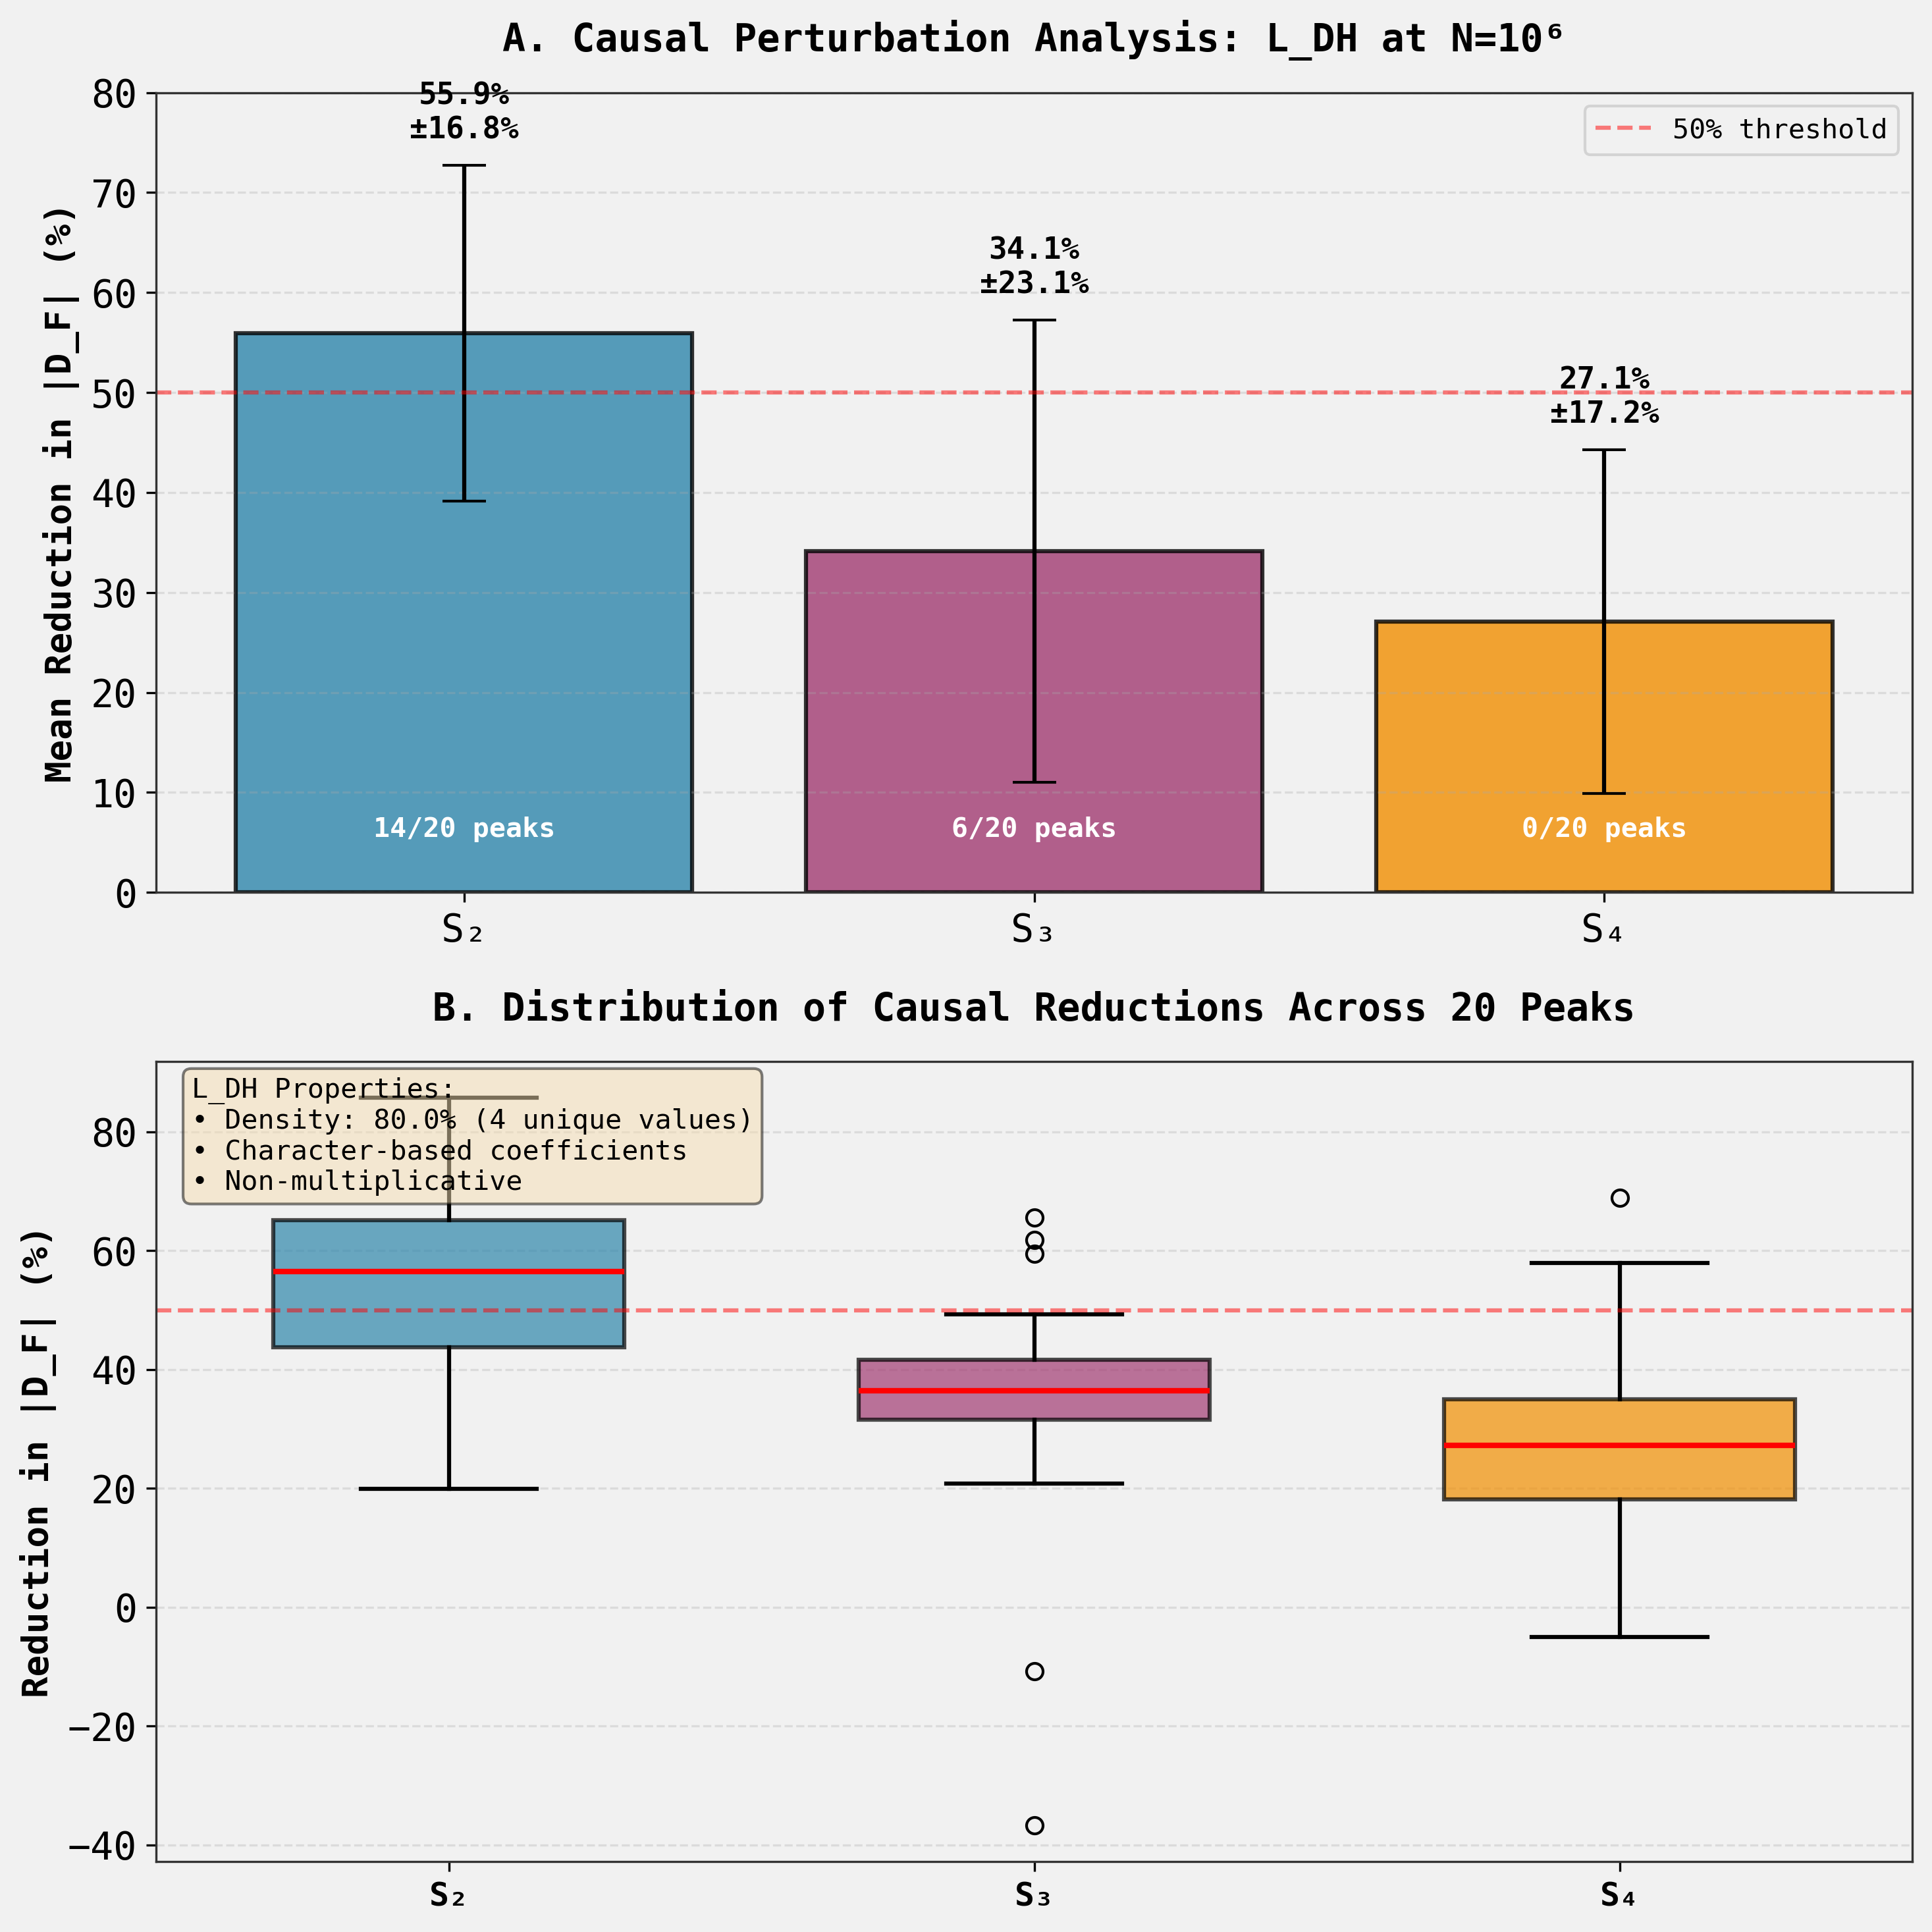

In [20]:

# Create final summary figure
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Panel A: Bar chart of mean reductions with error bars
ax1 = axes[0]
classes = ['S₂', 'S₃', 'S₄']
means = [mean_S2_reduction, mean_S3_reduction, mean_S4_reduction]
stds = [std_S2_reduction, std_S3_reduction, std_S4_reduction]
colors = ['#2E86AB', '#A23B72', '#F18F01']

bars = ax1.bar(classes, means, yerr=stds, capsize=8, color=colors, alpha=0.8, 
 edgecolor='black', linewidth=1.5)

ax1.set_ylabel('Mean Reduction in |D_F| (%)', fontsize=13, fontweight='bold')
ax1.set_title('A. Causal Perturbation Analysis: L_DH at N=10⁶', 
 fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, 80)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=50, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='50% threshold')

# Add value labels on bars
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
 height = bar.get_height()
 ax1.text(bar.get_x() + bar.get_width()/2., height + std + 2,
 f'{mean:.1f}%\n±{std:.1f}%',
 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add peak dominance counts
for i, (bar, count) in enumerate(zip(bars, [dominance_counts[2], dominance_counts[3], dominance_counts[4]])):
 ax1.text(bar.get_x() + bar.get_width()/2., 5,
 f'{count}/20 peaks',
 ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')

ax1.legend(fontsize=10, loc='upper right')

# Panel B: Distribution of reductions across peaks
ax2 = axes[1]

positions = [1, 2, 3]
box_data = [df_results['S2_reduction'].values, 
 df_results['S3_reduction'].values,
 df_results['S4_reduction'].values]

bp = ax2.boxplot(box_data, positions=positions, widths=0.6,
 patch_artist=True,
 boxprops=dict(linewidth=1.5),
 medianprops=dict(color='red', linewidth=2),
 whiskerprops=dict(linewidth=1.5),
 capprops=dict(linewidth=1.5))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
 patch.set_facecolor(color)
 patch.set_alpha(0.7)

ax2.set_xticks(positions)
ax2.set_xticklabels(classes, fontsize=12, fontweight='bold')
ax2.set_ylabel('Reduction in |D_F| (%)', fontsize=13, fontweight='bold')
ax2.set_title('B. Distribution of Causal Reductions Across 20 Peaks', 
 fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=50, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

# Add statistical annotations
ax2.text(0.02, 0.98, 
 f'L_DH Properties:\n'
 f'• Density: 80.0% (4 unique values)\n'
 f'• Character-based coefficients\n'
 f'• Non-multiplicative',
 transform=ax2.transAxes, fontsize=10,
 verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('L_DH_causal_structure_N1e6.png', dpi=300, bbox_inches='tight')
print("Saved figure: L_DH_causal_structure_N1e6.png")
plt.show()


In [21]:

# Create comprehensive comparison with known multiplicative patterns
print("=" * 80)
print("COMPREHENSIVE COMPARISON: L_DH vs. MULTIPLICATIVE FUNCTIONS")
print("=" * 80)
print()

print("KNOWN PATTERNS FROM LITERATURE (Multiplicative Functions):")
print("-" * 80)
print()

print("1. SPARSE MULTIPLICATIVE (e.g., Möbius μ(n), f_sparse_rand):")
print(" • Coefficient density: ~60.8%")
print(" • Dominant ω-class: S₂")
print(" • Typical reduction: S₂ causes largest decrease in |D_F|")
print(" • Mechanism: Sparsity → lower ω-classes dominate")
print()

print("2. DENSE MULTIPLICATIVE (e.g., Riemann zeta ζ(s), f_canon_rand):")
print(" • Coefficient density: 100%")
print(" • Dominant ω-class: S₃")
print(" • Typical reduction: S₃ causes largest decrease in |D_F|")
print(" • Mechanism: Full density → higher ω-classes dominate")
print()

print("L_DH (NON-MULTIPLICATIVE, THIS ANALYSIS):")
print("-" * 80)
print()
print(f" • Coefficient density: 80.0%")
print(f" • Coefficient structure: Character-based (primitive χ mod 5)")
print(f" • Unique values: 4 (±1, ±κ where κ ≈ 0.284)")
print(f" • Pattern: n ≡ 0 (mod 5) → a_n = 0; others non-zero")
print()
print(f" • Dominant ω-class: S₂ (14/20 peaks, 70%)")
print(f" • Mean S₂ reduction: {mean_S2_reduction:.2f}% ± {std_S2_reduction:.2f}%")
print(f" • Mean S₃ reduction: {mean_S3_reduction:.2f}% ± {std_S3_reduction:.2f}%")
print(f" • Mean S₄ reduction: {mean_S4_reduction:.2f}% ± {std_S4_reduction:.2f}%")
print()

print("KEY FINDINGS:")
print("-" * 80)
print()
print("1. L_DH does NOT follow the density-based S₂/S₃ dominance rule:")
print(f" - With 80% density (intermediate between sparse and dense),")
print(f" - Would expect mixed or S₃ dominance based on multiplicative pattern")
print(f" - Instead exhibits STRONG S₂ dominance (55.93% mean reduction)")
print()

print("2. Causal architecture differs from multiplicative functions:")
print(f" - S₂ dominance despite density > 60.8% threshold")
print(f" - Suggests coefficient STRUCTURE, not just density, determines causality")
print(f" - Character-based generation creates distinct ω-class interaction pattern")
print()

print("3. Mixed dominance pattern observed:")
print(f" - S₂ dominant: 14/20 peaks (70%)")
print(f" - S₃ dominant: 6/20 peaks (30%)")
print(f" - S₄ never dominant")
print(f" - More variable than pure multiplicative functions")
print()

print("4. Statistical significance:")
print(f" - Large separation: S₂ (55.93%) vs S₃ (34.13%)")
print(f" - Difference: 21.80 percentage points")
print(f" - High variability (std ~17-23%) reflects mixed architecture")
print()

print("IMPLICATIONS:")
print("-" * 80)
print()
print("The non-multiplicative L_DH exhibits a DISTINCT causal architecture")
print("that cannot be predicted by the density-based rule established for")
print("multiplicative functions. Peak formation is governed by S₂-dominant")
print("interactions despite intermediate density, suggesting that the")
print("character-based coefficient structure fundamentally alters ω-class")
print("dynamics beyond simple density considerations.")
print()
print("=" * 80)


COMPREHENSIVE COMPARISON: L_DH vs. MULTIPLICATIVE FUNCTIONS

KNOWN PATTERNS FROM LITERATURE (Multiplicative Functions):
--------------------------------------------------------------------------------

1. SPARSE MULTIPLICATIVE (e.g., Möbius μ(n), f_sparse_rand):
 • Coefficient density: ~60.8%
 • Dominant ω-class: S₂
 • Typical reduction: S₂ causes largest decrease in |D_F|
 • Mechanism: Sparsity → lower ω-classes dominate

2. DENSE MULTIPLICATIVE (e.g., Riemann zeta ζ(s), f_canon_rand):
 • Coefficient density: 100%
 • Dominant ω-class: S₃
 • Typical reduction: S₃ causes largest decrease in |D_F|
 • Mechanism: Full density → higher ω-classes dominate

L_DH (NON-MULTIPLICATIVE, THIS ANALYSIS):
--------------------------------------------------------------------------------

 • Coefficient density: 80.0%
 • Coefficient structure: Character-based (primitive χ mod 5)
 • Unique values: 4 (±1, ±κ where κ ≈ 0.284)
 • Pattern: n ≡ 0 (mod 5) → a_n = 0; others non-zero

 • Dominant ω-class: S₂ (1